# Gaussian Process Regression - Temperature Dataset

In [689]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from numpy import ndarray

sns.set_theme(style="white", context="notebook")

RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

## Formatting data

In [690]:
import pandas as pd

data = pd.read_csv('data/Daily_Temp_Data.csv')
data['date'] = pd.to_datetime(data['date'], dayfirst=True) # Ensure date is in datetime format
filtered = data[(data.date >= '2010-01-01') & (data.date <= '2022-12-31')]
filtered.describe()

,date,temp
count,4748,4748.000000
mean,2016-07-01 12:00:00,20.526029
min,2010-01-01 00:00:00,10.735000
25%,2013-04-01 18:00:00,17.263854
50%,2016-07-01 12:00:00,20.857142
75%,2019-10-01 06:00:00,23.815417
max,2022-12-31 00:00:00,30.074167
std,NaN,3.893950


In [691]:
filtered.set_index("date", inplace=True)
data_w = filtered.temp.resample("W").mean().dropna().to_frame()
data_w.head()

,temp
date,
2010-01-03,25.624028
2010-01-10,24.694940
2010-01-17,25.337679
2010-01-24,25.573795
2010-01-31,25.854631


In [692]:
training = data_w[data_w.index.year <= 2019]
training.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 522 entries, 2010-01-03 to 2019-12-29
Freq: W-SUN
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    522 non-null    float64
dtypes: float64(1)
memory usage: 8.2 KB


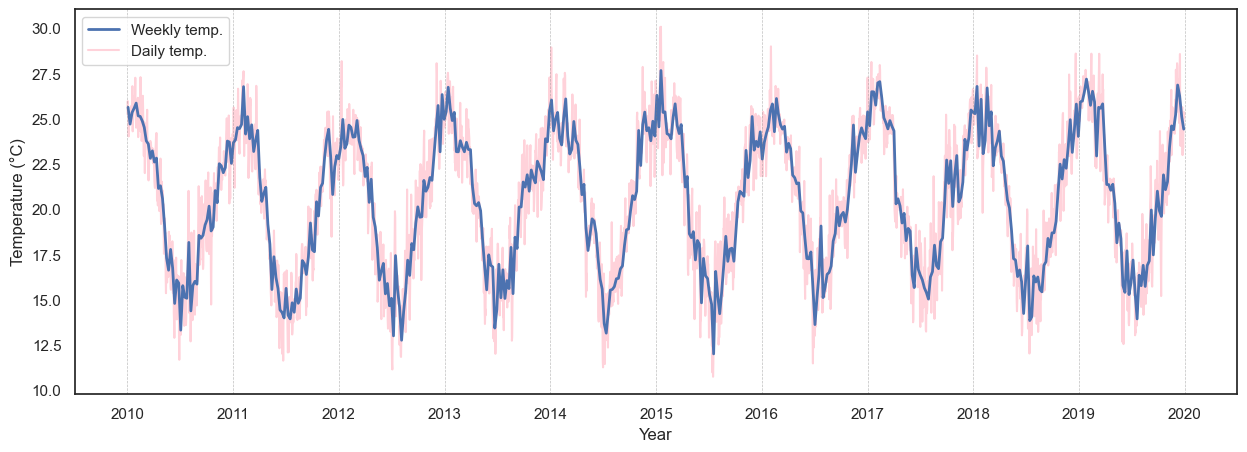

In [693]:
# Plot daily and weekly data over 2010-2020
plt.figure(figsize=(15, 5))

# Weekly mean
sns.lineplot(x=training.index, y=training.temp, lw=2, label="Weekly temp.")

# Daily mean
dummy = filtered[filtered.index.year <= 2019]
sns.lineplot(x=dummy.index, y=dummy.temp, c="pink", alpha=0.7, zorder=-1, label="Daily temp.")

# Add vbars for years
years = np.arange(2010, 2021)
for y in years:
    plt.axvline(pd.Timestamp(f'{y}-01-01'), color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

In [694]:
X = ((training.index - training.index.min()).days / 7).to_numpy()
y = training.temp.to_numpy()
y_mean = y.mean()

In [695]:
y -= y_mean # Mean centering for GP
y_mean

np.float64(20.558568211747858)

## Fitting a GP

In [696]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import *

kernel_lin = ConstantKernel(1.0) * RBF(52.0 * 10)
kernel_per = ConstantKernel(1.0) * ExpSineSquared(length_scale=1.0, periodicity=52.2, periodicity_bounds="fixed") * RBF(52.0 * 10)
kernel_irr = ConstantKernel(1.0) * RationalQuadratic(length_scale=1.0, alpha=1.0)
kernel_noi = ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(1.0, noise_level_bounds=(1e-5, 1e1))
kernel = kernel_lin + kernel_per + kernel_irr + kernel_noi

In [697]:
kernel = ConstantKernel(1.0) * RBF(1000.0) + ConstantKernel(1.0) * ExpSineSquared(1.0, periodicity=52.2, periodicity_bounds="fixed") + WhiteKernel(1.0)

In [698]:
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

n_restarts = 3
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=n_restarts, random_state=RANDOM_SEED)

In [699]:
gp.fit(X, y)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1e+03) + 1**2 * ExpSineSquared(length_scale=1, periodicity=52.2) + WhiteKernel(noise_level=1),
                         n_restarts_optimizer=3, random_state=0)

In [700]:
gp.kernel_

0.497**2 * RBF(length_scale=54.8) + 9.91**2 * ExpSineSquared(length_scale=3.51, periodicity=52.2) + WhiteKernel(noise_level=1.09)

## Analysing model fit

In [701]:
print(f"R^2 = {gp.score(X, y) :.4f}")

R^2 = 0.9229


In [702]:
gp.log_marginal_likelihood_value_

np.float64(-789.0978420404903)

In [721]:
import matplotlib.ticker as ticker

def visualise_gpr(
        gp: GaussianProcessRegressor, data: list = None, extra_data: list = None,
        start: float = None, end: float = None, n: float = 100, figsize: tuple = (12, 6),
        x_init_year: float = 2010, include_year_lines: bool = False):
    """Visualise a fitted GP model. Should work so that you can optionally pass the observations or
    forecast data (ie test data). If you don't pass the time bounds `(start, end)`, then it'll try 
    finding the bounds of the index in `data[0]`.

    Args:
        gp (GaussianProcessRegressor): The fitted GP regressor.
        data (list, optional): Observations `(t, f(t))`. Defaults to None.
        extra_data (list, optional): Additional data for forecast comparison `(t, f(t))`. Defaults to None.
        start (float, optional): Left time bound for plotting. Defaults to None.
        end (float, optional): Right time bound for plotting. Defaults to None.
        n (float, optional): Number of points. Defaults to 100.
    """
    bounds_bool = start is not None and end is not None
    assert bounds_bool or (data)
    if not bounds_bool:
        start = data[0].min()
        end = data[0].max()
    y_mean = data[1].mean() if data else 0.0

    plt.figure(figsize=figsize)

    # 1. GP Prediction (Uses numerical X)
    X_plot = np.linspace(start, end, int(n)).reshape(-1, 1)
    y_pred_centered, sigma_centered = gp.predict(X_plot, return_std=True)
    X_plot = X_plot.ravel()
    y_pred = y_pred_centered.ravel() + y_mean
    sigma = sigma_centered.ravel()

    X_plot = X_plot / 52.0 + x_init_year

    # print(X_plot.min(), X_plot.max())
    # print(extra_data[0].min(), extra_data[0].max())

    # Posterior mean and uncertainty band
    sns.lineplot(x=X_plot, y=y_pred, lw=2, c="orange", label="Posterior Mean")
    plt.fill_between(
        X_plot, y_pred - 2 * sigma, y_pred + 2 * sigma, 
        color="orange", alpha=0.25, label="\u00B1 2 x std", zorder=-10
    )

    # Observations
    if data:
        sns.scatterplot(x=data[0] / 52.0 + x_init_year, y=data[1], s=10, lw=0, label="Observations", zorder=2)

    # Future data
    if extra_data:
        sns.scatterplot(x=extra_data[0] / 52.0 + x_init_year, y=extra_data[1], marker="x", s=10, lw=1, label="Future data", zorder=2, color="red")

    if include_year_lines:
        years = np.arange(X_plot.min(), X_plot.max()+1)
        for y in years:
            plt.axvline(y, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=-5)

    # xticks = np.arange(0, X_plot.max(), 52)
    # xlabels = (x_init_year + pd.to_timedelta(xticks * 7, unit="D")).year
    # plt.xticks(xticks, xlabels.astype(str))

    # plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, y: f"{x_init_year + (x / 52.0):.0f}"))

    plt.xticks(np.arange(start/52.0 + x_init_year, end/52.0 + x_init_year+1, 1))
    # plt.xlim(left=x_init_year)

    plt.xlabel("Year")
    plt.ylabel("Temperature (°C)")
    plt.show()


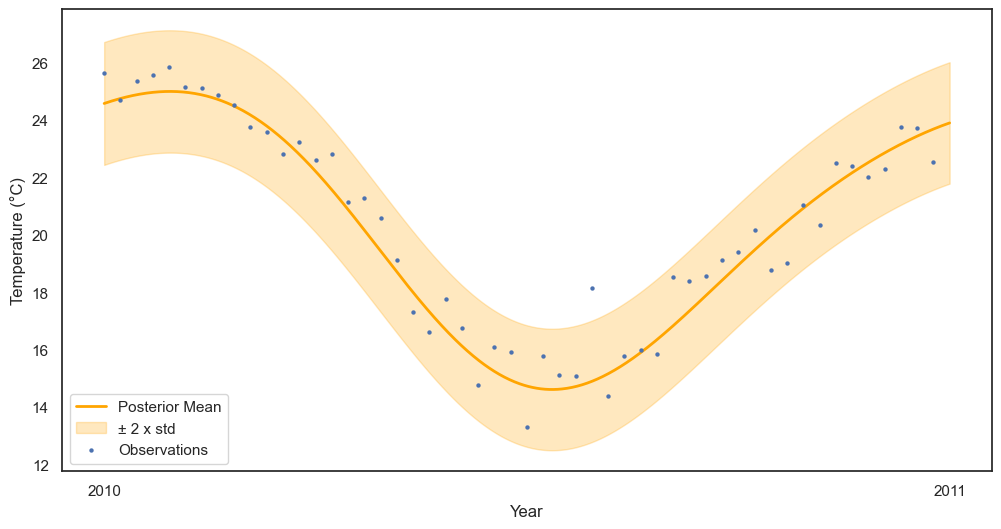

In [723]:
visualise_gpr(gp, [X.ravel()[:52], y.ravel()[:52] + y_mean], start=0, end=52, n=1000)

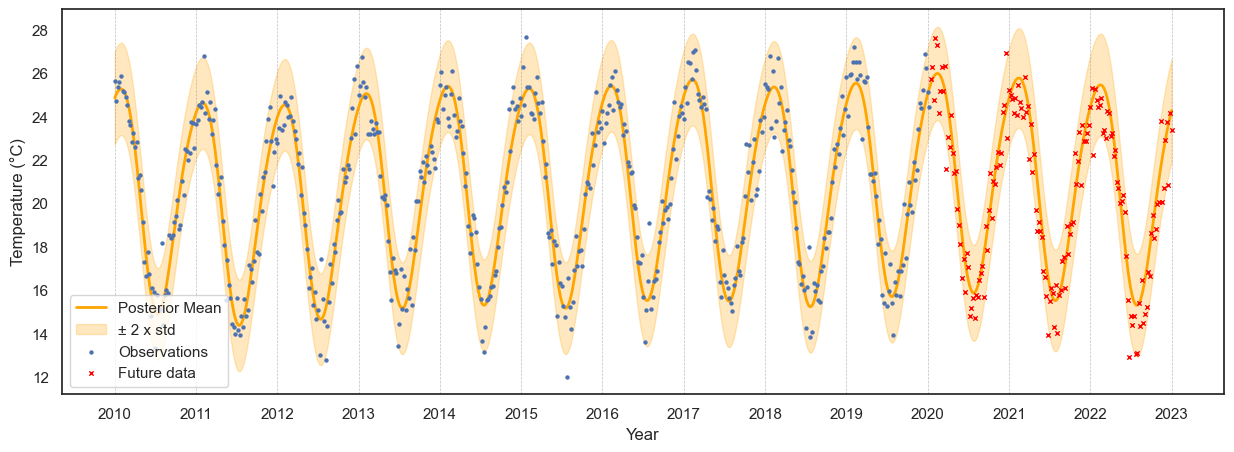

In [722]:
START = X.min()
END = X.max()
N_POINTS = 1000
FORECAST = 52.0 * 3-1

# data = [X.ravel()[52*8:], y.ravel()[52*8:] + y_mean]
data = [X.ravel(), y.ravel() + y_mean]
extra_df = data_w[data_w.index.year > 2019][:-2]
extra = [((extra_df.index - extra_df.index.min()).days / 7).to_numpy() + 52.0*10+2, extra_df.temp.to_numpy()]
visualise_gpr(gp, data, extra, START, END + FORECAST, N_POINTS, (15,5), 2010, True)
# visualise_gpr(gp, data, None, START, END, N_POINTS, (15,5), 2010, True)

<Axes: xlabel='date', ylabel='temp'>

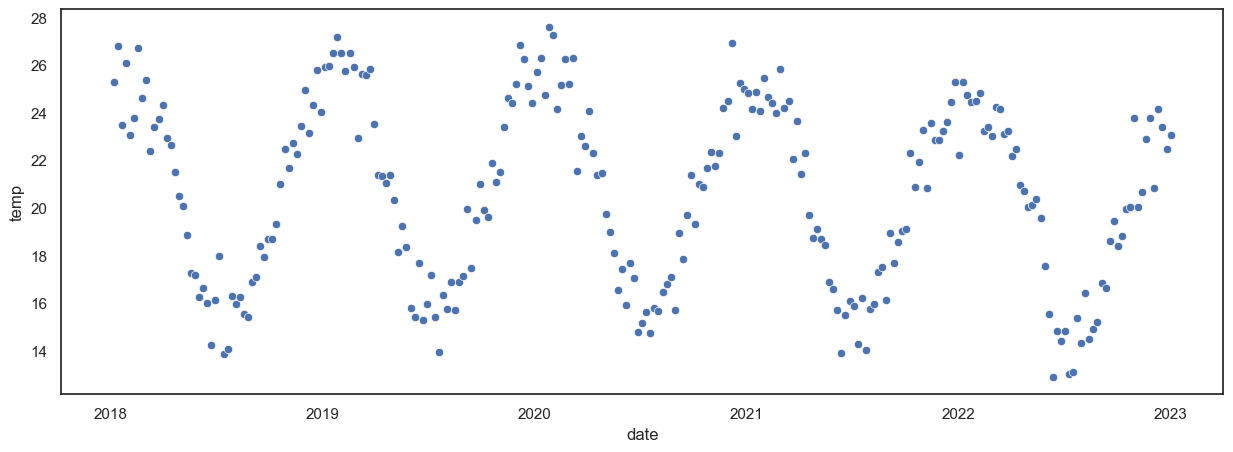

In [706]:
dummy = data_w[data_w.index.year >= 2018]
plt.figure(figsize=(15,5))
sns.scatterplot(x=dummy.index, y=dummy.temp)

In [707]:
from sklearn.metrics import r2_score

forecast_pred = gp.predict(extra[0].reshape(-1, 1)) + y_mean
r2_score(forecast_pred, extra[1])

0.8868911009814077

## Visualising inidividual kernel components

With the main GP fitted and plotted, we can finish the interpretation by plotting the individual kernels to understand what the learned hyperparameters are doing.

In [708]:
gp.kernel_

0.497**2 * RBF(length_scale=54.8) + 9.91**2 * ExpSineSquared(length_scale=3.51, periodicity=52.2) + WhiteKernel(noise_level=1.09)

0.497**2 * RBF(length_scale=54.8)
9.91**2 * ExpSineSquared(length_scale=3.51, periodicity=52.2)


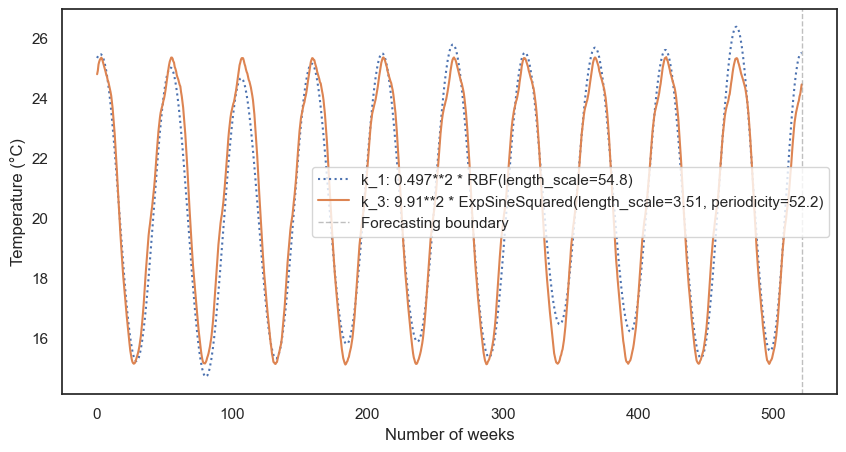

In [717]:
ker = gp.kernel_.k1.k1
print(ker)

gp_k1 = GaussianProcessRegressor(kernel=ker, alpha=1e-10, optimizer=None)
gp_k1.fit(X, y)

x_k1 = np.linspace(START, END, 1000)
y_k1 = gp_k1.predict(x_k1.reshape(-1, 1)) + y_mean

plt.figure(figsize=(10,5))
sns.lineplot(x=x_k1, y=y_k1, linestyle=":", label=f"k_1: {ker}")

ker = gp.kernel_.k1.k2
print(ker)

gp_k1 = GaussianProcessRegressor(kernel=ker, alpha=1e-10, optimizer=None)
gp_k1.fit(X, y)

x_k1 = np.linspace(START, END, 1000)
y_k1 = gp_k1.predict(x_k1.reshape(-1, 1)) + y_mean

sns.lineplot(x=x_k1, y=y_k1, linestyle="-", label=f"k_3: {ker}")
plt.axvline(END, color='gray', linestyle='--', lw=1, alpha=0.5, label="Forecasting boundary")
plt.xlabel("Number of weeks")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()